<a href="https://colab.research.google.com/github/aadithyansudarsan/ML-EXPERIMENTS/blob/main/Exp-4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, load_diabetes
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.metrics import mean_squared_error,r2_score

In [ ]:
from sklearn.datasets import load_diabetes

diabetes = load_diabetes()
x = diabetes.data
y = diabetes.target

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

print("training samples:",x_train.shape)
print("testing samples:",x_test.shape)

training samples: (353, 10)
testing samples: (89, 10)


### Model Training and Evaluation

In [ ]:
# Linear Regression
linear_model = LinearRegression()
linear_model.fit(x_train, y_train)
y_pred_linear = linear_model.predict(x_test)

In [ ]:
# Ridge Regression with GridSearchCV
ridge = Ridge()
param_grid_ridge = {'alpha': np.logspace(-4, 0, 10)}
ridge_cv = GridSearchCV(ridge, param_grid_ridge, cv=5)
ridge_cv.fit(x_train, y_train)

best_ridge = ridge_cv.best_estimator_
y_pred_ridge = best_ridge.predict(x_test)

In [ ]:
result = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge', 'Lasso '],
    'MSE': [
        mean_squared_error(y_test, y_pred_linear),
        mean_squared_error(y_test, y_pred_ridge),
        mean_squared_error(y_test, y_pred_lasso)
    ],
    'R2': [
        r2_score(y_test, y_pred_linear),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso)
    ]
})
print(result)

               Model          MSE        R2
0  Linear Regression  2900.193628  0.452603
1              Ridge  2892.014566  0.454147
2             Lasso   2824.568094  0.466877


In [ ]:
lasso = Lasso()
param_grid_lasso = {'alpha': np.logspace(-4, 0, 10)}
lasso_cv = GridSearchCV(lasso, param_grid_lasso, cv=5)
lasso_cv.fit(x_train, y_train)

best_lasso = lasso_cv.best_estimator_
y_pred_lasso = best_lasso.predict(x_test)

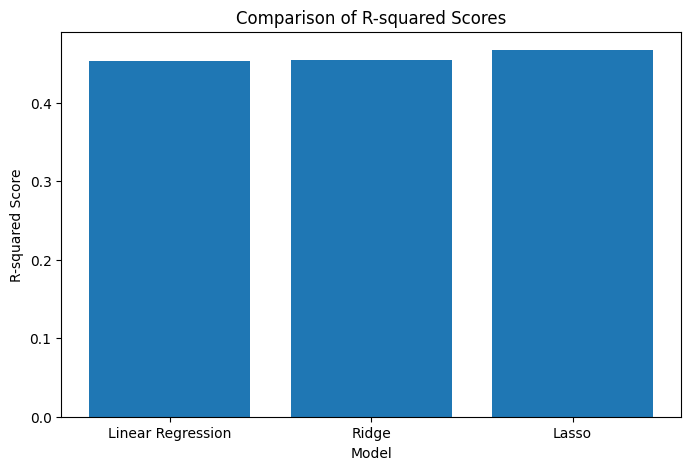

In [ ]:
plt.figure(figsize=(8, 5))
models = ['Linear Regression', 'Ridge', 'Lasso']
r2_scores = [r2_score(y_test, y_pred_linear), r2_score(y_test, y_pred_ridge), r2_score(y_test, y_pred_lasso)]
plt.bar(models, r2_scores)
plt.xlabel('Model')
plt.ylabel('R-squared Score')
plt.title('Comparison of R-squared Scores')
plt.show()